In [62]:
"""
importartando las librerias necesarias, se carga el dataset_elpino

"""
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
import time
import numpy as np
import pandas as pd

#  Configuración opcional
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)

#  Cargar dataset
df = pd.read_csv("dataset_elpino.csv", sep=";", encoding="utf-8")

#  Ver primeras filas
df.head()

,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des),Diag 06 Secundario (cod+des),Diag 07 Secundario (cod+des),Diag 08 Secundario (cod+des),Diag 09 Secundario (cod+des),Diag 10 Secundario (cod+des),Diag 11 Secundario (cod+des),Diag 12 Secundario (cod+des),Diag 13 Secundario (cod+des),Diag 14 Secundario (cod+des),Diag 15 Secundario (cod+des),Diag 16 Secundario (cod+des),Diag 17 Secundario (cod+des),Diag 18 Secundario (cod+des),Diag 19 Secundario (cod+des),Diag 20 Secundario (cod+des),Diag 21 Secundario (cod+des),Diag 22 Secundario (cod+des),Diag 23 Secundario (cod+des),Diag 24 Secundario (cod+des),Diag 25 Secundario (cod+des),Diag 26 Secundario (cod+des),Diag 27 Secundario (cod+des),Diag 28 Secundario (cod+des),Diag 29 Secundario (cod+des),Diag 30 Secundario (cod+des),Diag 31 Secundario (cod+des),Diag 32 Secundario (cod+des),Diag 33 Secundario (cod+des),Diag 34 Secundario (cod+des),Diag 35 Secundario (cod+des),Proced 01 Principal (cod+des),Proced 02 Secundario (cod+des),Proced 03 Secundario (cod+des),Proced 04 Secundario (cod+des),Proced 05 Secundario (cod+des),Proced 06 Secundario (cod+des),Proced 07 Secundario (cod+des),Proced 08 Secundario (cod+des),Proced 09 Secundario (cod+des),Proced 10 Secundario (cod+des),Proced 11 Secundario (cod+des),Proced 12 Secundario (cod+des),Proced 13 Secundario (cod+des),Proced 14 Secundario (cod+des),Proced 15 Secundario (cod+des),Proced 16 Secundario (cod+des),Proced 17 Secundario (cod+des),Proced 18 Secundario (cod+des),Proced 19 Secundario (cod+des),Proced 20 Secundario (cod+des),Proced 21 Secundario (cod+des),Proced 22 Secundario (cod+des),Proced 23 Secundario (cod+des),Proced 24 Secundario (cod+des),Proced 25 Secundario (cod+des),Proced 26 Secundario (cod+des),Proced 27 Secundario (cod+des),Proced 28 Secundario (cod+des),Proced 29 Secundario (cod+des),Proced 30 Secundario (cod+des),Edad en años,Sexo (Desc),GRD
0,A41.8 - Otras septicemias especificadas,B37.6 - Endocarditis debida a candida (I39.8*),"I39.8 - Endocarditis, válvula no especificada,...",N10 - Nefritis tubulointersticial aguda,B96.1 - Klebsiella pneumoniae [K. pneumoniae] ...,L89.9 - Úlcera de decúbito y area de presión n...,L08.9 - Infección local de la piel y del tejid...,B96.2 - Escherichia coli [E. coli] como causa ...,A41.5 - Sepsis por otros organnismos Gram nega...,J86.9 - Piotórax sin fístula,"U07.1 - COVID-19, virus identificado",Y95 - Afección nosocomial,"N18.5 - Enfermedad renal crónica, estadio 5",E87.1 - Hiposmolaridad e hiponatremia,D64.9 - Anemia de tipo no especificado,"G82.2 - Paraplejía, no especificada","N31.9 - Disfunción neuromuscular de la vejiga,...",I10 - Hipertensión esencial (primaria),K70.4 - Insuficiencia hepática alcohólica,F19.2 - Trastornos mentales y del comportamien...,F10.2 - Trastornos mentales y del comportamien...,"E46 - Desnutrición proteicocalórica, no especi...","G40.9 - Epilepsia, tipo no especificado","L21.9 - Dermatitis seborreica, no especificada",Z93.5 - Cistostomía,Z93.3 - Colostomía,Z99.2 - Dependencia de diálisis renal,Z91.6 - Historia personal de otro trauma físico,-,-,-,-,-,-,-,"86.28 - DESBRIDAMIENTO HERIDA,INFECCION O QUEM...",34.91 - TORACOCENTESIS,88.38 - TOMOGRAFIA AXIAL COMPUTERIZADA OTRA,87.41 - TOMOGRAFIA AXIAL COMPUTERIZADA TORAX,88.75 - ECOGRAFIA APARATO URINARIO,88.01 - TOMOGRAFIA AXIAL COMPUTERIZADA ABDOMEN,88.43 - ARTERIOGRAFIA ARTERIA PULMONAR,88.41 - ARTERIOGRAFIA ARTERIA CEREBRAL,87.44 - RADIOGRAFIA TORAX RUTINARIA,99.29 - INYECCION SUSTANCIA TERAPEUTICA O PROF...,99.19 - INYECCION ANTICOAGULANTE,99.18 - INYECCION ELECTROLITO,99.21 - INYECCION ANTIBIOTICO,99.26 - INYECCION TRANQUILIZANTE,99.23 - INYECCION ESTEROIDE,93.94 - AEROSOLTERAPIA,89.52 - ELECTROCARDIOGRAFIA,90.59 - EXAMEN MICROSCOPICO SANGRE.OTRO,89.65 - GASOMETRIA ARTERIA,39.95 - HEMODIALISIS,39.95 - HEMODIALISIS,99.04 - TRANSFUSION CONCENTRADO HEMATIES,90.39 - EXAMEN MICROSCOPICO ORL.OTRO,99.84 - AISLAMIENTO,88.7

In [63]:
#Analizar como esta el dataset

# Dimensiones del dataset
print("Shape del dataset:", df.shape)

# Nombres de columnas
print("\nColumnas:")
print(df.columns.tolist())

# Tipos de datos
print("\nTipos de datos:")
print(df.dtypes)

# Valores nulos
print("\nValores nulos:")
print(df.isnull().sum())

Shape del dataset: (14561, 68)

Columnas:
['Diag 01 Principal (cod+des)', 'Diag 02 Secundario (cod+des)', 'Diag 03 Secundario (cod+des)', 'Diag 04 Secundario (cod+des)', 'Diag 05 Secundario (cod+des)', 'Diag 06 Secundario (cod+des)', 'Diag 07 Secundario (cod+des)', 'Diag 08 Secundario (cod+des)', 'Diag 09 Secundario (cod+des)', 'Diag 10 Secundario (cod+des)', 'Diag 11 Secundario (cod+des)', 'Diag 12 Secundario (cod+des)', 'Diag 13 Secundario (cod+des)', 'Diag 14 Secundario (cod+des)', 'Diag 15 Secundario (cod+des)', 'Diag 16 Secundario (cod+des)', 'Diag 17 Secundario (cod+des)', 'Diag 18 Secundario (cod+des)', 'Diag 19 Secundario (cod+des)', 'Diag 20 Secundario (cod+des)', 'Diag 21 Secundario (cod+des)', 'Diag 22 Secundario (cod+des)', 'Diag 23 Secundario (cod+des)', 'Diag 24 Secundario (cod+des)', 'Diag 25 Secundario (cod+des)', 'Diag 26 Secundario (cod+des)', 'Diag 27 Secundario (cod+des)', 'Diag 28 Secundario (cod+des)', 'Diag 29 Secundario (cod+des)', 'Diag 30 Secundario (cod+des)'

In [64]:
#Clasificar las clases mas significativas (los GRD que mas casos tienen)

# Número de clases únicas
num_clases = df["GRD"].nunique()
print("Número de clases (GRD):", num_clases)

# Conteo de ejemplos por clase
class_counts = df["GRD"].value_counts()

print("\nTop 10 clases más frecuentes:")
print(class_counts.head(10))

print("\nClases menos frecuentes:")
print(class_counts.tail(10))

Número de clases (GRD): 526

Top 10 clases más frecuentes:
GRD
146101 - PH CESÁREA                                                                       813
146121 - PH PARTO VAGINAL CON PROCED., EXCEPTO ESTERILIZACIÓN Y/O DILATACIÓN Y LEGRADO    639
146131 - PH PARTO VAGINAL                                                                 538
158171 - MH NEONATO, PESO AL NACER >2499 GR SIN PROCEDIMIENTO MAYOR                       389
134161 - MH TRASTORNOS DEL ANTEPARTO                                                      325
071141 - PH COLECISTECTOMÍA LAPAROSCÓPICA                                                 317
044153 - MH INFECCIONES E INFLAMACIONES RESPIRATORIAS W/MCC                               287
061131 - PH PROCEDIMIENTOS SOBRE APÉNDICE                                                 252
041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SIN TRAQUEOSTOMÍA W/MCC                       248
146102 - PH CESÁREA W/CC                                                                  2

In [65]:
#LIMPIEZA DE LOS DATOS

#Extraemos los codigos de la columna GRD
df["GRD_codigo"] = df["GRD"].apply(lambda x: str(x).split(" - ")[0])

#Seleccionamos el top 30 de GRDs con mas datos
top_n = 30

top_classes = df["GRD_codigo"].value_counts().head(top_n).index

df = df[df["GRD_codigo"].isin(top_classes)].copy()

print("Nuevo número de clases:", df["GRD_codigo"].nunique())
print("Nuevo tamaño dataset:", df.shape)

# LIMPIAMOS LOS CODIGOS DE DIAGNOSTICOS
diag_cols = [col for col in df.columns if "Diag" in col]

def limpiar_codigos(row):
    codigos = []
    for col in diag_cols:
        val = str(row[col])
        if val != "-" and val != "nan":
            codigo = val.split(" - ")[0]
            codigos.append(codigo)
    return " ".join(codigos)

df["Diagnosticos"] = df.apply(limpiar_codigos, axis=1)

#LIMPIAMOS LOS CODIGOS DE PROCEDIMEINTOS
proc_cols = [col for col in df.columns if "Proced" in col]

def limpiar_procedimientos(row):
    codigos = []
    for col in proc_cols:
        val = str(row[col])
        if val != "-" and val != "nan":
            codigo = val.split(" - ")[0]
            codigos.append(codigo)
    return " ".join(codigos)

df["Procedimientos"] = df.apply(limpiar_procedimientos, axis=1)

#BINARIZAMOS LA COLUMNA DE SEXO
df["Sexo_binario"] = df["Sexo (Desc)"].map({
    "Hombre": 1,
    "Mujer": 0
})

#SEPARAMOS VARIABELS TEXTUALES Y VARIABLES NUMERICAS
#ESTANDARIZAMOS LA VARIABLE OBJETIVO
X_text_diag = df["Diagnosticos"]
X_text_proc = df["Procedimientos"]
X_edad = df["Edad en años"]
X_sexo = df["Sexo_binario"]

y = df["GRD_codigo"]

#VECTORIZAMOS LOS DIAGNOSTICOS
from sklearn.feature_extraction.text import CountVectorizer

vectorizer_diag = CountVectorizer()
X_diag = vectorizer_diag.fit_transform(X_text_diag)

#VECTRIZAMOS LOS PROCEDIMIENTOS
vectorizer_proc = CountVectorizer()
X_proc = vectorizer_proc.fit_transform(X_text_proc)

#UNIMOS DIAGNOSTICOS Y PROCEDIMEINTOS
from scipy.sparse import hstack

X = hstack([X_diag, X_proc])

#AGREGAR EDAD Y SEXO
import numpy as np

X_extra = np.array([X_edad, X_sexo]).T

from scipy.sparse import csr_matrix

X = hstack([X, csr_matrix(X_extra)])

print("Shape final de X:", X.shape)
print("Número de clases:", y.nunique())

Nuevo número de clases: 30
Nuevo tamaño dataset: (7106, 69)
Shape final de X: (7106, 1135)
Número de clases: 30


In [66]:
#ESTRATIFICACION DE LOS DATOS
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y

"""
SEPARAMOS EL DATA SET EN UNA PROPORCION 80 / 20, DEJANDO 80% PARA
EL ENTRENAMIENTO Y 20% PARA EL TEST.
"""
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nDistribución clases en TRAIN:")
print(y_train.value_counts(normalize=True).head())

print("\nDistribución clases en TEST:")
print(y_test.value_counts(normalize=True).head())

Train shape: (5684, 1135)
Test shape: (1422, 1135)

Distribución clases en TRAIN:
GRD_codigo
146101    0.114356
146121    0.089901
146131    0.075651
158171    0.054715
134161    0.045742
Name: proportion, dtype: float64

Distribución clases en TEST:
GRD_codigo
146101    0.114627
146121    0.090014
146131    0.075949
158171    0.054852
134161    0.045710
Name: proportion, dtype: float64


In [67]:
#ENCODEAMOS LAS CLASES
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

num_classes = len(le.classes_)

In [68]:
#CONTENEDOR DE RESULTADOS
resultados_modelos = []

In [69]:
"""
MODELO 1 (CARACTERÍSTICAS):
Capas ocultas = 1
N° de perceptrones por capa:
- 128 (Densa)

Métodos utilizados:
- Activación ReLU
- Softmax en salida
- Adam Optimizer
- Estratificación
"""
# DEFINICION DE MODELO
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ENTRENAMIENTO DE MODELO (Con medicion de tiempo)
start_train = time.time()

history = model.fit(
    X_train.toarray(),
    y_train_enc,
    epochs=15,
    batch_size=32,
    verbose=1
)

end_train = time.time()

print("\nTiempo de entrenamiento:", end_train - start_train, "segundos")

# PRUEBA DEL MODELO
start_test = time.time()

y_pred_prob_1 = model.predict(X_test.toarray())
y_pred_1 = np.argmax(y_pred_prob, axis=1)

end_test = time.time()

print("Tiempo de test:", end_test - start_test, "segundos")

# METRICAS
accuracy_1 = accuracy_score(y_test_enc, y_pred)

print("\nAccuracy:", accuracy)

print("\nReporte completo:")
print(classification_report(y_test_enc, y_pred))

#GUARDANDO RESULTADOS DEL MODELO

from sklearn.metrics import f1_score

macro_f1 = f1_score(
    y_test_enc,
    y_pred_1,
    average='macro'
)

weighted_f1 = f1_score(
    y_test_enc,
    y_pred_1,
    average='weighted'
)

resultados_modelos.append({

    "Modelo": "Modelo 1",

    "Accuracy": accuracy_1,

    "Macro_F1": macro_f1,

    "Weighted_F1": weighted_f1,

    "Tiempo_Entrenamiento": end_train - start_train,

    "Tiempo_Test": end_test - start_test
})

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5924 - loss: 1.8224
Epoch 2/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8302 - loss: 0.6426
Epoch 3/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8765 - loss: 0.4118
Epoch 4/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9096 - loss: 0.3046
Epoch 5/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9245 - loss: 0.2459
Epoch 6/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9391 - loss: 0.2014
Epoch 7/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9465 - loss: 0.1717
Epoch 8/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9521 - loss: 0.1527
Epoch 9/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9553 - loss: 0.1386
Epoch 10/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9580 - loss: 0.1289
Epoch 11/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9660 - loss: 0.1132
Epoch 12/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy

In [70]:
"""
MODELO 2 (CARACTERÍSTICAS):
Capas ocultas = 1
N° de perceptrones por capa:
- 128 (Densa)

Métodos utilizados:
- Activación ReLU
- Softmax en salida
- Adam Optimizer
- Class Weight
- Estratificación
"""
from sklearn.utils.class_weight import compute_class_weight

import numpy as np

classes = np.unique(y_train_enc)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_enc
)

class_weights = dict(zip(classes, weights))

print("Class weights:", class_weights)

#ARQUITECTURA
model_2 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(num_classes, activation='softmax')
])

model_2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#ENTRENAMIENTO
import time

start_train = time.time()

history_2 = model_2.fit(
    X_train.toarray(),
    y_train_enc,
    epochs=15,
    batch_size=32,
    class_weight=class_weights,   # 🔥 AQUÍ ESTÁ LA MAGIA
    verbose=1
)

end_train = time.time()

print("\nTiempo de entrenamiento:", end_train - start_train, "segundos")

#PREDICCIÓN
start_test = time.time()

y_pred_prob_2 = model_2.predict(X_test.toarray())
y_pred_2 = np.argmax(y_pred_prob_2, axis=1)

end_test = time.time()

print("Tiempo de test:", end_test - start_test, "segundos")

#METRICAS
from sklearn.metrics import classification_report, accuracy_score

accuracy_2 = accuracy_score(y_test_enc, y_pred_2)

print("\nAccuracy:", accuracy_2)

print("\nReporte completo:")
print(classification_report(y_test_enc, y_pred_2))


#GUARDAR RESULTADOS

from sklearn.metrics import f1_score

macro_f1 = f1_score(
    y_test_enc,
    y_pred_2,
    average='macro'
)

weighted_f1 = f1_score(
    y_test_enc,
    y_pred_2,
    average='weighted'
)

resultados_modelos.append({

    "Modelo": "Modelo 2",

    "Accuracy": accuracy_2,

    "Macro_F1": macro_f1,

    "Weighted_F1": weighted_f1,

    "Tiempo_Entrenamiento": end_train - start_train,

    "Tiempo_Test": end_test - start_test
})


Class weights: {np.int64(0): np.float64(1.9532646048109965), np.int64(1): np.float64(0.9569023569023569), np.int64(2): np.float64(1.8217948717948718), np.int64(3): np.float64(0.823768115942029), np.int64(4): np.float64(1.0353369763205829), np.int64(5): np.float64(1.6333333333333333), np.int64(6): np.float64(1.754320987654321), np.int64(7): np.float64(1.1623721881390594), np.int64(8): np.float64(0.9379537953795379), np.int64(9): np.float64(1.540379403794038), np.int64(10): np.float64(2.2827309236947793), np.int64(11): np.float64(0.7459317585301837), np.int64(12): np.float64(1.839482200647249), np.int64(13): np.float64(2.0594202898550726), np.int64(14): np.float64(1.7707165109034269), np.int64(15): np.float64(1.7382262996941895), np.int64(16): np.float64(1.9943859649122806), np.int64(17): np.float64(1.0467771639042358), np.int64(18): np.float64(1.0644194756554306), np.int64(19): np.float64(1.706906906906907), np.int64(20): np.float64(0.7287179487179487), np.int64(21): np.float64(0.291487

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5315 - loss: 1.9762
Epoch 2/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7991 - loss: 0.7396
Epoch 3/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8691 - loss: 0.4453
Epoch 4/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9015 - loss: 0.3205
Epoch 5/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9207 - loss: 0.2502
Epoch 6/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9331 - loss: 0.2006
Epoch 7/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9423 - loss: 0.1718
Epoch 8/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9470 - loss: 0.1500
Epoch 9/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9534 - loss: 0.1304
Epoch 10/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9550 - loss: 0.1178
Epoch 11/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9601 - loss: 0.1052
Epoch 12/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy

In [71]:
"""
MODELO 3 (CARACTERÍSTICAS):
Capas ocultas = 1
N° de perceptrones por capa:
- 128 (Densa)

Métodos utilizados:
- Activación ReLU
- Dropout (0.3)
- Softmax en salida
- Adam Optimizer
- Class Weight
- Estratificación
"""
from tensorflow.keras.layers import Dropout

model_3 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),   # 🔥 AQUÍ ESTÁ LA NUEVA PARTE
    Dense(num_classes, activation='softmax')
])

model_3.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#ENTRENA CON CALSS WEIGHT
import time

start_train = time.time()

history_3 = model_3.fit(
    X_train.toarray(),
    y_train_enc,
    epochs=15,
    batch_size=32,
    class_weight=class_weights,
    verbose=1
)

end_train = time.time()

print("\nTiempo de entrenamiento:", end_train - start_train, "segundos")

#PREDICCION
start_test = time.time()

y_pred_prob_3 = model_3.predict(X_test.toarray())
y_pred_3 = np.argmax(y_pred_prob_3, axis=1)

end_test = time.time()

print("Tiempo de test:", end_test - start_test, "segundos")

#METRICAS
accuracy_3 = accuracy_score(y_test_enc, y_pred_3)

print("\nAccuracy:", accuracy_3)

print("\nReporte completo:")
print(classification_report(y_test_enc, y_pred_3))


#GUARDANDO RESULTADOS

from sklearn.metrics import f1_score

macro_f1 = f1_score(
    y_test_enc,
    y_pred_3,
    average='macro'
)

weighted_f1 = f1_score(
    y_test_enc,
    y_pred_3,
    average='weighted'
)

resultados_modelos.append({

    "Modelo": "Modelo 3",

    "Accuracy": accuracy_3,

    "Macro_F1": macro_f1,

    "Weighted_F1": weighted_f1,

    "Tiempo_Entrenamiento": end_train - start_train,

    "Tiempo_Test": end_test - start_test
})

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3527 - loss: 2.4862
Epoch 2/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6682 - loss: 1.1118
Epoch 3/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7637 - loss: 0.7065
Epoch 4/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8190 - loss: 0.5113
Epoch 5/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8476 - loss: 0.4170
Epoch 6/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8798 - loss: 0.3344
Epoch 7/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8885 - loss: 0.2936
Epoch 8/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9027 - loss: 0.2613
Epoch 9/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9129 - loss: 0.2253
Epoch 10/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9215 - loss: 0.2057
Epoch 11/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9317 - loss: 0.1779
Epoch 12/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy

In [72]:
"""
MODELO 4 (CARACTERÍSTICAS):
Capas ocultas = 2
N° de perceptrones por capa:
- 128 (Densa)
- 64 (Densa)

Métodos utilizados:
- Activación ReLU
- Softmax en salida
- Adam Optimizer
- Class Weight
- Estratificación
"""

model_4 = Sequential([

    # Primera capa oculta
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),

    # Segunda capa oculta
    Dense(64, activation='relu'),

    # Capa de salida
    Dense(num_classes, activation='softmax')
])

#COMPILACION
model_4.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#ENTRENAMIENTO
import time

start_train = time.time()

history_4 = model_4.fit(
    X_train.toarray(),
    y_train_enc,
    epochs=15,
    batch_size=32,
    class_weight=class_weights,
    verbose=1
)

end_train = time.time()

print("\nTiempo de entrenamiento:", end_train - start_train, "segundos")

#PREDICCION
start_test = time.time()

y_pred_prob_4 = model_4.predict(X_test.toarray())
y_pred_4 = np.argmax(y_pred_prob_4, axis=1)

end_test = time.time()

print("Tiempo de test:", end_test - start_test, "segundos")

#METRICAS
accuracy_4 = accuracy_score(y_test_enc, y_pred_4)

print("\nAccuracy:", accuracy_4)

print("\nReporte completo:")
print(classification_report(y_test_enc, y_pred_4))

GUARDANDO RESULTADOS

from sklearn.metrics import f1_score

macro_f1 = f1_score(
    y_test_enc,
    y_pred_4,
    average='macro'
)

weighted_f1 = f1_score(
    y_test_enc,
    y_pred_4,
    average='weighted'
)

resultados_modelos.append({

    "Modelo": "Modelo 4",

    "Accuracy": accuracy_4,

    "Macro_F1": macro_f1,

    "Weighted_F1": weighted_f1,

    "Tiempo_Entrenamiento": end_train - start_train,

    "Tiempo_Test": end_test - start_test
})

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3811 - loss: 2.2079
Epoch 2/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7275 - loss: 0.7874
Epoch 3/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8262 - loss: 0.4532
Epoch 4/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8809 - loss: 0.3224
Epoch 5/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9112 - loss: 0.2415
Epoch 6/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9282 - loss: 0.1886
Epoch 7/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9404 - loss: 0.1578
Epoch 8/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9470 - loss: 0.1359
Epoch 9/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9451 - loss: 0.1168
Epoch 10/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9509 - loss: 0.1069
Epoch 11/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9567 - loss: 0.0928
Epoch 12/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy

In [73]:
"""
MODELO 5 (CARACTERÍSTICAS):
Capas ocultas = 3
N° de perceptrones por capa:
- 256 (Densa)
- 128 (Densa)
- 64 (Densa)

Métodos utilizados:
- Activación ReLU
- Dropout
- Softmax en salida
- Adam Optimizer
- Class Weight
- Estratificación
"""

from tensorflow.keras.layers import Dropout

model_5 = Sequential([

    # Primera capa oculta
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),

    # Dropout
    Dropout(0.2),

    # Segunda capa oculta
    Dense(64, activation='relu'),

    # Capa de salida
    Dense(num_classes, activation='softmax')
])

#COMPILACION
model_5.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#ENTRENAMIENTO
import time

start_train = time.time()

history_5 = model_5.fit(
    X_train.toarray(),
    y_train_enc,
    epochs=15,
    batch_size=32,
    class_weight=class_weights,
    verbose=1
)

end_train = time.time()

print("\nTiempo de entrenamiento:", end_train - start_train, "segundos")

#PREDICCION
start_test = time.time()

y_pred_prob_5 = model_5.predict(X_test.toarray())
y_pred_5 = np.argmax(y_pred_prob_5, axis=1)

end_test = time.time()

print("Tiempo de test:", end_test - start_test, "segundos")

#METRICAS
accuracy_5 = accuracy_score(y_test_enc, y_pred_5)

print("\nAccuracy:", accuracy_5)

print("\nReporte completo:")
print(classification_report(y_test_enc, y_pred_5))

#GRANDES RESULTADOS

from sklearn.metrics import f1_score

macro_f1 = f1_score(
    y_test_enc,
    y_pred_5,
    average='macro'
)

weighted_f1 = f1_score(
    y_test_enc,
    y_pred_5,
    average='weighted'
)

resultados_modelos.append({

    "Modelo": "Modelo 5",

    "Accuracy": accuracy_5,

    "Macro_F1": macro_f1,

    "Weighted_F1": weighted_f1,

    "Tiempo_Entrenamiento": end_train - start_train,

    "Tiempo_Test": end_test - start_test
})

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3480 - loss: 2.4917
Epoch 2/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6761 - loss: 0.9751
Epoch 3/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7825 - loss: 0.5792
Epoch 4/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8299 - loss: 0.4230
Epoch 5/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8751 - loss: 0.3238
Epoch 6/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8958 - loss: 0.2723
Epoch 7/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9097 - loss: 0.2287
Epoch 8/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9175 - loss: 0.2028
Epoch 9/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9300 - loss: 0.1717
Epoch 10/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9307 - loss: 0.1564
Epoch 11/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9405 - loss: 0.1352
Epoch 12/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy

In [74]:
"""
MODELO 6 (CARACTERÍSTICAS):
Capas ocultas = 4
N° de perceptrones por capa:
- 512 (Densa)
- 256 (Densa)
- 128 (Densa)
- 64 (Densa)

Métodos utilizados:
- Activación ReLU
- Dropout
- Softmax en salida
- Adam Optimizer
- Class Weight
- Estratificación
"""

model_6 = Sequential([

    # Primera capa oculta
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),

    # Segunda capa oculta
    Dense(128, activation='relu'),

    # Tercera capa oculta
    Dense(64, activation='relu'),

    # Capa de salida
    Dense(num_classes, activation='softmax')
])

#COMPILACION
model_6.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#ENTRENAMIENTO
import time

start_train = time.time()

history_6 = model_6.fit(
    X_train.toarray(),
    y_train_enc,
    epochs=15,
    batch_size=32,
    class_weight=class_weights,
    verbose=1
)

end_train = time.time()

print("\nTiempo de entrenamiento:", end_train - start_train, "segundos")

#PREICCION
start_test = time.time()

y_pred_prob_6 = model_6.predict(X_test.toarray())
y_pred_6 = np.argmax(y_pred_prob_6, axis=1)

end_test = time.time()

print("Tiempo de test:", end_test - start_test, "segundos")

#METRICAS
accuracy_6 = accuracy_score(y_test_enc, y_pred_6)

print("\nAccuracy:", accuracy_6)

print("\nReporte completo:")
print(classification_report(y_test_enc, y_pred_6))

#GUARDAR RESULTADOS

from sklearn.metrics import f1_score

macro_f1 = f1_score(
    y_test_enc,
    y_pred_6,
    average='macro'
)

weighted_f1 = f1_score(
    y_test_enc,
    y_pred_6,
    average='weighted'
)

resultados_modelos.append({

    "Modelo": "Modelo 6",

    "Accuracy": accuracy_6,

    "Macro_F1": macro_f1,

    "Weighted_F1": weighted_f1,

    "Tiempo_Entrenamiento": end_train - start_train,

    "Tiempo_Test": end_test - start_test
})

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4217 - loss: 2.0014
Epoch 2/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7551 - loss: 0.6639
Epoch 3/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8575 - loss: 0.3782
Epoch 4/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8980 - loss: 0.2653
Epoch 5/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9069 - loss: 0.2153
Epoch 6/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9344 - loss: 0.1656
Epoch 7/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9388 - loss: 0.1338
Epoch 8/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9412 - loss: 0.1243
Epoch 9/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9506 - loss: 0.1095
Epoch 10/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9543 - loss: 0.0946
Epoch 11/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9546 - loss: 0.0938
Epoch 12/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accurac

In [75]:
"""
MODELO 7 (CARACTERÍSTICAS):
Capas ocultas = 3
N° de perceptrones por capa:
- 256 (Densa)
- 128 (Densa)
- 64 (Densa)

Métodos utilizados:
- Activación ReLU
- Dropout
- Early Stopping
- Validation Split
- Softmax en salida
- Adam Optimizer
- Class Weight
- Estratificación
"""

from tensorflow.keras.callbacks import EarlyStopping

model_7 = Sequential([

    # Primera capa oculta
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),

    # Segunda capa oculta
    Dense(64, activation='relu'),

    # Capa de salida
    Dense(num_classes, activation='softmax')
])

#COMPILACION
model_7.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#EARLYSPOPPING
early_stop = EarlyStopping(

    # Métrica monitoreada
    monitor='val_loss',

    # Espera 3 epochs antes de detener
    patience=3,

    # Recupera los mejores pesos
    restore_best_weights=True
)

#ENTRENAMIENTO
import time

start_train = time.time()

history_7 = model_7.fit(
    X_train.toarray(),
    y_train_enc,

    epochs=30,

    batch_size=32,

    class_weight=class_weights,

    validation_split=0.2,

    callbacks=[early_stop],

    verbose=1
)

end_train = time.time()

print("\nTiempo de entrenamiento:", end_train - start_train, "segundos")

#PREDICCION
start_test = time.time()

y_pred_prob_7 = model_7.predict(X_test.toarray())
y_pred_7 = np.argmax(y_pred_prob_7, axis=1)

end_test = time.time()

print("Tiempo de test:", end_test - start_test, "segundos")

#METRICAS
accuracy_7 = accuracy_score(y_test_enc, y_pred_7)

print("\nAccuracy:", accuracy_7)

print("\nReporte completo:")
print(classification_report(y_test_enc, y_pred_7))

#GUARDAR RESULTADOS

from sklearn.metrics import f1_score

macro_f1 = f1_score(
    y_test_enc,
    y_pred_7,
    average='macro'
)

weighted_f1 = f1_score(
    y_test_enc,
    y_pred_7,
    average='weighted'
)

resultados_modelos.append({

    "Modelo": "Modelo 7",

    "Accuracy": accuracy_7,

    "Macro_F1": macro_f1,

    "Weighted_F1": weighted_f1,

    "Tiempo_Entrenamiento": end_train - start_train,

    "Tiempo_Test": end_test - start_test
})

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


143/143 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4135 - loss: 2.3037 - val_accuracy: 0.6306 - val_loss: 1.2337
Epoch 2/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7376 - loss: 0.8841 - val_accuracy: 0.8056 - val_loss: 0.6494
Epoch 3/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8157 - loss: 0.5161 - val_accuracy: 0.8478 - val_loss: 0.5011
Epoch 4/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8797 - loss: 0.3521 - val_accuracy: 0.8056 - val_loss: 0.5208
Epoch 5/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9035 - loss: 0.2710 - val_accuracy: 0.8391 - val_loss: 0.4365
Epoch 6/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9186 - loss: 0.2088 - val_accuracy: 0.8848 - val_loss: 0.3420
Epoch 7/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9314 - loss: 0.1742 - val_accuracy: 0.8813 - val_loss: 0.3747
Epoch 8/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9393 - loss: 0.1487 - val_accuracy: 0.8953 - val_

In [76]:
"""
MODELO 8 (CARACTERÍSTICAS):
Capas ocultas = 2
N° de perceptrones por capa:
- 64 (Densa)
- 32 (Densa)

Métodos utilizados:
- Activación ReLU
- Softmax en salida
- Adam Optimizer
- Class Weight
- Estratificación
"""

model_8 = Sequential([

    # Primera capa oculta
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),

    # Segunda capa oculta
    Dense(32, activation='relu'),

    # Capa de salida
    Dense(num_classes, activation='softmax')
])

#COMPILACION
model_8.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#ENTRENAMIENTO
import time

start_train = time.time()

history_8 = model_8.fit(
    X_train.toarray(),
    y_train_enc,
    epochs=15,
    batch_size=32,
    class_weight=class_weights,
    verbose=1
)

end_train = time.time()

print("\nTiempo de entrenamiento:", end_train - start_train, "segundos")

#PREDICCION
start_test = time.time()

y_pred_prob_8 = model_8.predict(X_test.toarray())
y_pred_8 = np.argmax(y_pred_prob_8, axis=1)

end_test = time.time()

print("Tiempo de test:", end_test - start_test, "segundos")

#METRICAS
accuracy_8 = accuracy_score(y_test_enc, y_pred_8)

print("\nAccuracy:", accuracy_8)

print("\nReporte completo:")
print(classification_report(y_test_enc, y_pred_8))

#GUARDAR RESULTADOS

from sklearn.metrics import f1_score

macro_f1 = f1_score(
    y_test_enc,
    y_pred_8,
    average='macro'
)

weighted_f1 = f1_score(
    y_test_enc,
    y_pred_8,
    average='weighted'
)

resultados_modelos.append({

    "Modelo": "Modelo 8",

    "Accuracy": accuracy_8,

    "Macro_F1": macro_f1,

    "Weighted_F1": weighted_f1,

    "Tiempo_Entrenamiento": end_train - start_train,

    "Tiempo_Test": end_test - start_test
})

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3147 - loss: 2.5658
Epoch 2/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6916 - loss: 1.0380
Epoch 3/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7789 - loss: 0.6002
Epoch 4/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8357 - loss: 0.4275
Epoch 5/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8827 - loss: 0.3315
Epoch 6/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8980 - loss: 0.2681
Epoch 7/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9192 - loss: 0.2151
Epoch 8/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9275 - loss: 0.1852
Epoch 9/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9360 - loss: 0.1592
Epoch 10/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9453 - loss: 0.1382
Epoch 11/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9463 - loss: 0.1226
Epoch 12/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

In [77]:
"""
MODELO 9 (CARACTERÍSTICAS):
Capas ocultas = 2
N° de perceptrones por capa:
- 128 (Densa)
- 64 (Densa)

Métodos utilizados:
- Activación ReLU
- Regularización L2
- Softmax en salida
- Adam Optimizer
- Class Weight
- Estratificación
"""

from tensorflow.keras.regularizers import l2

model_9 = Sequential([

    # Primera capa oculta con L2
    Dense(
        128,
        activation='relu',
        kernel_regularizer=l2(0.001),
        input_shape=(X_train.shape[1],)
    ),

    # Segunda capa oculta con L2
    Dense(
        64,
        activation='relu',
        kernel_regularizer=l2(0.001)
    ),

    # Capa de salida
    Dense(
        num_classes,
        activation='softmax'
    )
])

#COMILACION

model_9.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#ENTRENAMIENTO

import time

start_train = time.time()

history_9 = model_9.fit(

    X_train.toarray(),
    y_train_enc,

    epochs=15,

    batch_size=32,

    class_weight=class_weights,

    verbose=1
)

end_train = time.time()

print("\nTiempo de entrenamiento:",
      end_train - start_train,
      "segundos")

#PREDICCION

start_test = time.time()

y_pred_prob_9 = model_9.predict(
    X_test.toarray()
)

y_pred_9 = np.argmax(
    y_pred_prob_9,
    axis=1
)

end_test = time.time()

print("Tiempo de test:",
      end_test - start_test,
      "segundos")

#METRICAS
accuracy_9 = accuracy_score(
    y_test_enc,
    y_pred_9
)

print("\nAccuracy:", accuracy_9)

print("\nReporte completo:")

print(
    classification_report(
        y_test_enc,
        y_pred_9
    )
)

#GUARDAR RESULTADOS

from sklearn.metrics import f1_score

macro_f1 = f1_score(
    y_test_enc,
    y_pred_9,
    average='macro'
)

weighted_f1 = f1_score(
    y_test_enc,
    y_pred_9,
    average='weighted'
)

resultados_modelos.append({

    "Modelo": "Modelo 9",

    "Accuracy": accuracy_9,

    "Macro_F1": macro_f1,

    "Weighted_F1": weighted_f1,

    "Tiempo_Entrenamiento": end_train - start_train,

    "Tiempo_Test": end_test - start_test
})

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4616 - loss: 2.2848
Epoch 2/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7224 - loss: 0.9885
Epoch 3/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8070 - loss: 0.7238
Epoch 4/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8527 - loss: 0.6210
Epoch 5/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8709 - loss: 0.5620
Epoch 6/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8981 - loss: 0.5282
Epoch 7/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9076 - loss: 0.4962
Epoch 8/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9036 - loss: 0.4778
Epoch 9/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9126 - loss: 0.4674
Epoch 10/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9198 - loss: 0.4434
Epoch 11/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9319 - loss: 0.4193
Epoch 12/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accurac

In [78]:
"""
MODELO 10 (CARACTERÍSTICAS):
Capas ocultas = 2
N° de perceptrones por capa:
- 128 (Densa)
- 64 (Densa)

Métodos utilizados:
- Activación ReLU
- Batch Normalization
- Softmax en salida
- Adam Optimizer
- Class Weight
- Estratificación
"""

from tensorflow.keras.layers import BatchNormalization

model_10 = Sequential([

    # Primera capa
    Dense(
        128,
        activation='relu',
        input_shape=(X_train.shape[1],)
    ),

    # Batch Normalization
    BatchNormalization(),

    # Segunda capa
    Dense(
        64,
        activation='relu'
    ),

    # Batch Normalization
    BatchNormalization(),

    # Salida
    Dense(
        num_classes,
        activation='softmax'
    )
])

#COMPILACION

model_10.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#ENTRENAMIENTO

import time

start_train = time.time()

history_10 = model_10.fit(

    X_train.toarray(),
    y_train_enc,

    epochs=15,

    batch_size=32,

    class_weight=class_weights,

    verbose=1
)

end_train = time.time()

print("\nTiempo de entrenamiento:",
      end_train - start_train,
      "segundos")

#PREDICCION

start_test = time.time()

y_pred_prob_10 = model_10.predict(
    X_test.toarray()
)

y_pred_10 = np.argmax(
    y_pred_prob_10,
    axis=1
)

end_test = time.time()

print("Tiempo de test:",
      end_test - start_test,
      "segundos")

#METRICAS

accuracy_10 = accuracy_score(
    y_test_enc,
    y_pred_10
)

print("\nAccuracy:", accuracy_10)

print("\nReporte completo:")

print(
    classification_report(
        y_test_enc,
        y_pred_10
    )
)

#GUARDAR RESULTADOS

from sklearn.metrics import f1_score

macro_f1 = f1_score(
    y_test_enc,
    y_pred_10,
    average='macro'
)

weighted_f1 = f1_score(
    y_test_enc,
    y_pred_10,
    average='weighted'
)

resultados_modelos.append({

    "Modelo": "Modelo 10",

    "Accuracy": accuracy_10,

    "Macro_F1": macro_f1,

    "Weighted_F1": weighted_f1,

    "Tiempo_Entrenamiento": end_train - start_train,

    "Tiempo_Test": end_test - start_test
})

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5762 - loss: 1.5902
Epoch 2/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8494 - loss: 0.5040
Epoch 3/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9059 - loss: 0.3039
Epoch 4/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9222 - loss: 0.2122
Epoch 5/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9368 - loss: 0.1685
Epoch 6/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9430 - loss: 0.1330
Epoch 7/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9532 - loss: 0.1130
Epoch 8/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9594 - loss: 0.0985
Epoch 9/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9580 - loss: 0.0915
Epoch 10/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9602 - loss: 0.0825
Epoch 11/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9620 - loss: 0.0829
Epoch 12/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy

      Modelo  Accuracy  Macro_F1  Weighted_F1  Tiempo_Entrenamiento  \
0   Modelo 1  0.902250  0.887233     0.901030             15.907958   
1   Modelo 2  0.891702  0.878527     0.891617             17.739003   
2   Modelo 3  0.895921  0.888674     0.897722             15.332546   
3   Modelo 4  0.886779  0.875916     0.888144             15.966421   
4   Modelo 5  0.896624  0.884703     0.897651             18.371226   
5   Modelo 6  0.895218  0.881024     0.895656             20.845127   
6   Modelo 7  0.887482  0.868230     0.884391             13.732788   
7   Modelo 8  0.886779  0.874585     0.888132             14.636235   
8   Modelo 9  0.874121  0.860305     0.875159             17.612955   
9  Modelo 10  0.896624  0.878708     0.894634             19.567620   

   Tiempo_Test  
0     0.248612  
1     0.261708  
2     0.261892  
3     0.253720  
4     0.378906  
5     0.309012  
6     0.381516  
7     0.253032  
8     0.266433  
9     0.362254  


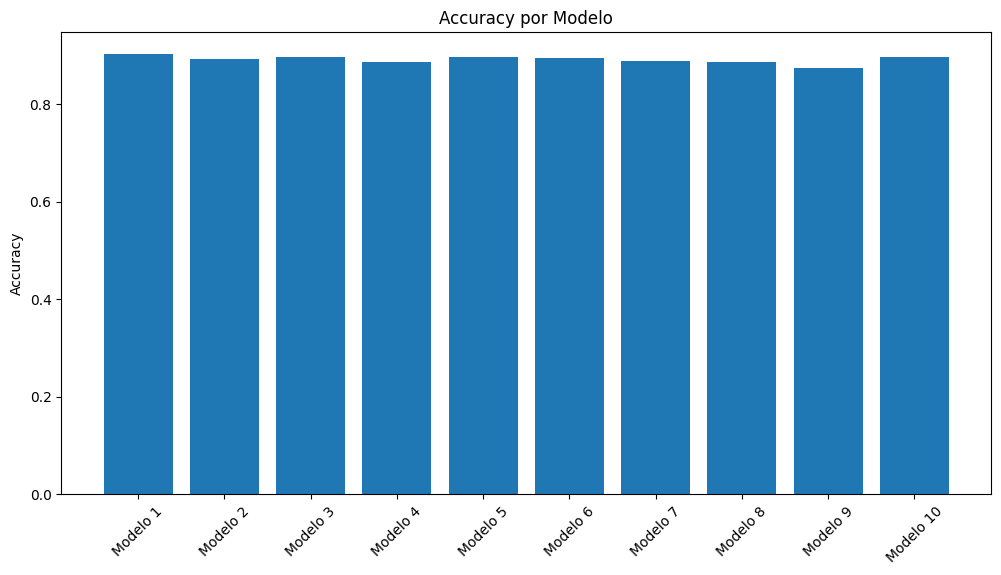

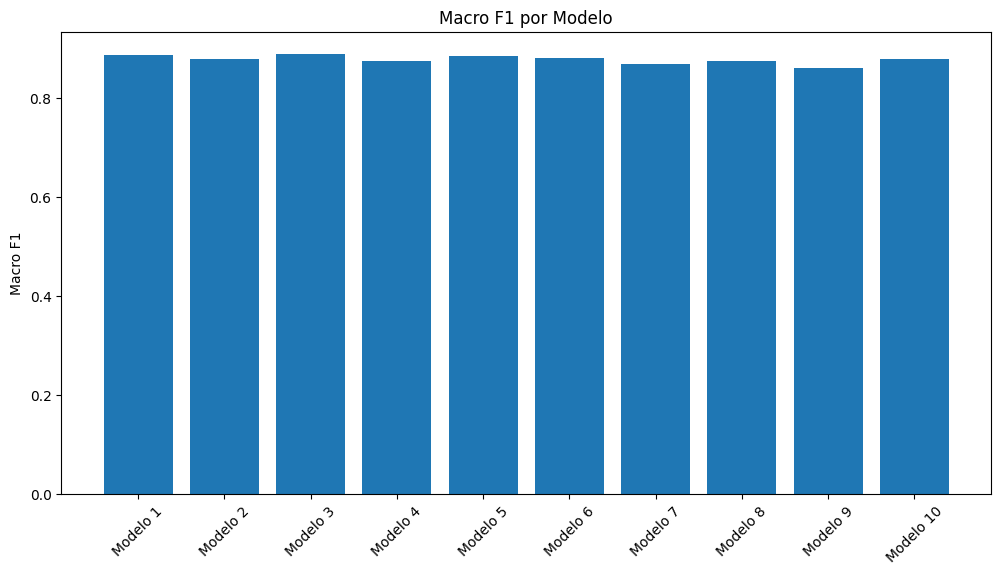

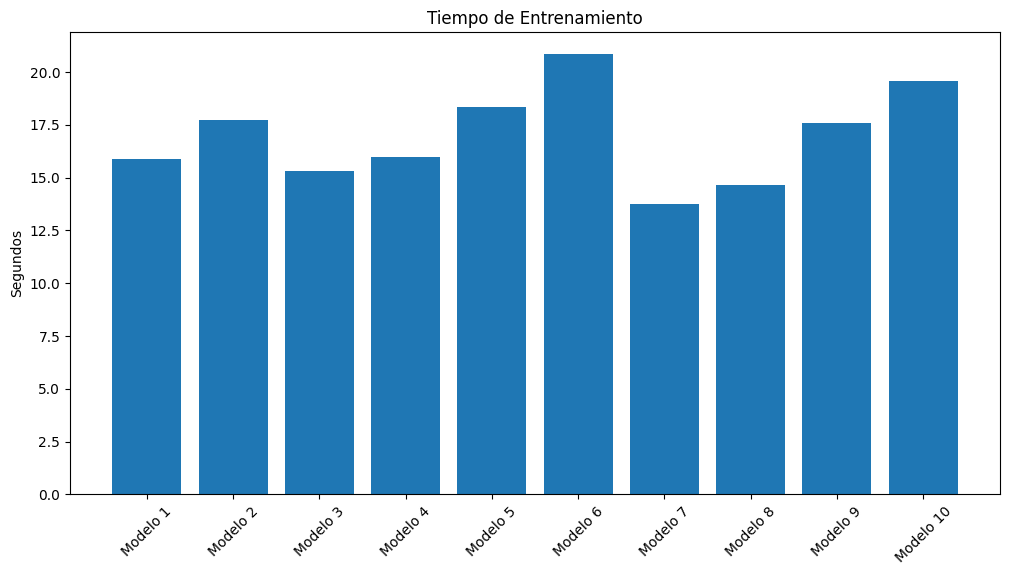

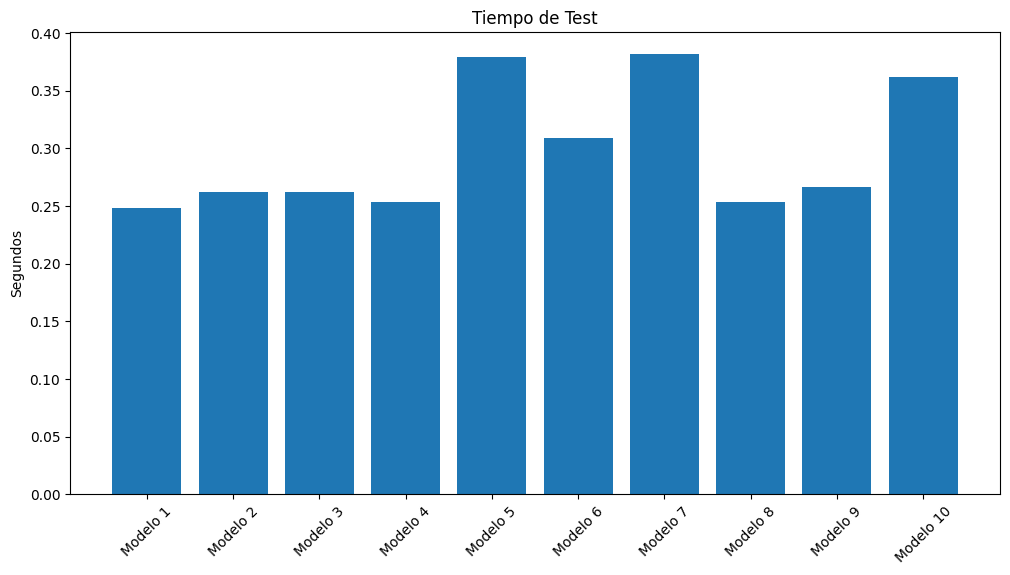

In [79]:
#TABLA RECOPILATORIA DE DATOS

import pandas as pd

df_resultados = pd.DataFrame(resultados_modelos)

print(df_resultados)

#GRAFICOS

import matplotlib.pyplot as plt

# ACCURACY
plt.figure(figsize=(12,6))

plt.bar(
    df_resultados["Modelo"],
    df_resultados["Accuracy"]
)

plt.title("Accuracy por Modelo")

plt.ylabel("Accuracy")

plt.xticks(rotation=45)

plt.show()

# MACRO F1
plt.figure(figsize=(12,6))

plt.bar(
    df_resultados["Modelo"],
    df_resultados["Macro_F1"]
)

plt.title("Macro F1 por Modelo")

plt.ylabel("Macro F1")

plt.xticks(rotation=45)

plt.show()

# TIEMPO ENTRENAMIENTO
plt.figure(figsize=(12,6))

plt.bar(
    df_resultados["Modelo"],
    df_resultados["Tiempo_Entrenamiento"]
)

plt.title("Tiempo de Entrenamiento")

plt.ylabel("Segundos")

plt.xticks(rotation=45)

plt.show()

# TIEMPO TEST
plt.figure(figsize=(12,6))

plt.bar(
    df_resultados["Modelo"],
    df_resultados["Tiempo_Test"]
)

plt.title("Tiempo de Test")

plt.ylabel("Segundos")

plt.xticks(rotation=45)

plt.show()

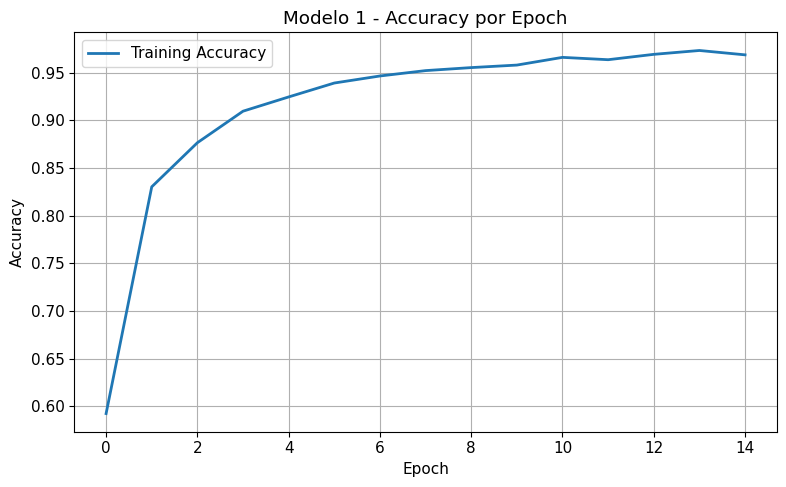

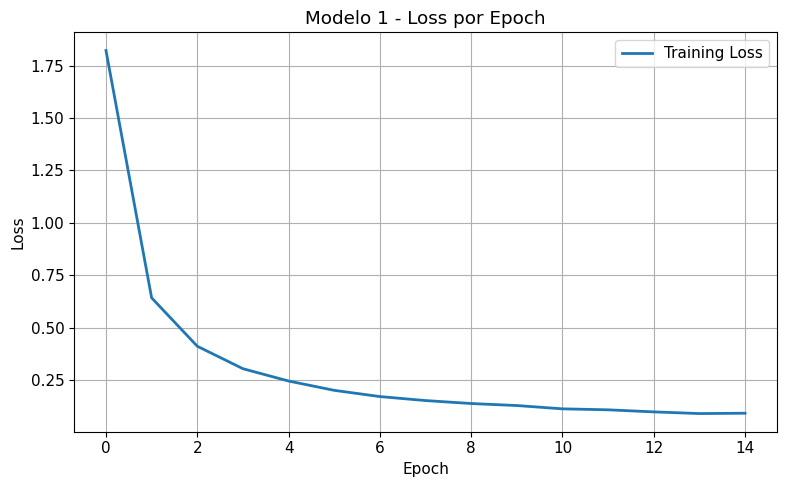

In [83]:
#CURBA DE ENTRENAMIENTO DEL MODELO 1

import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 11

plt.figure()

plt.plot(
    history.history['accuracy'],
    linewidth=2,
    label='Training Accuracy'
)

# VALIDACIÓN (si existe)
if 'val_accuracy' in history.history:

    plt.plot(
        history.history['val_accuracy'],
        linewidth=2,
        label='Validation Accuracy'
    )

plt.title('Modelo 1 - Accuracy por Epoch')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

plt.figure()

plt.plot(
    history.history['loss'],
    linewidth=2,
    label='Training Loss'
)


if 'val_loss' in history.history:

    plt.plot(
        history.history['val_loss'],
        linewidth=2,
        label='Validation Loss'
    )

plt.title('Modelo 1 - Loss por Epoch')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

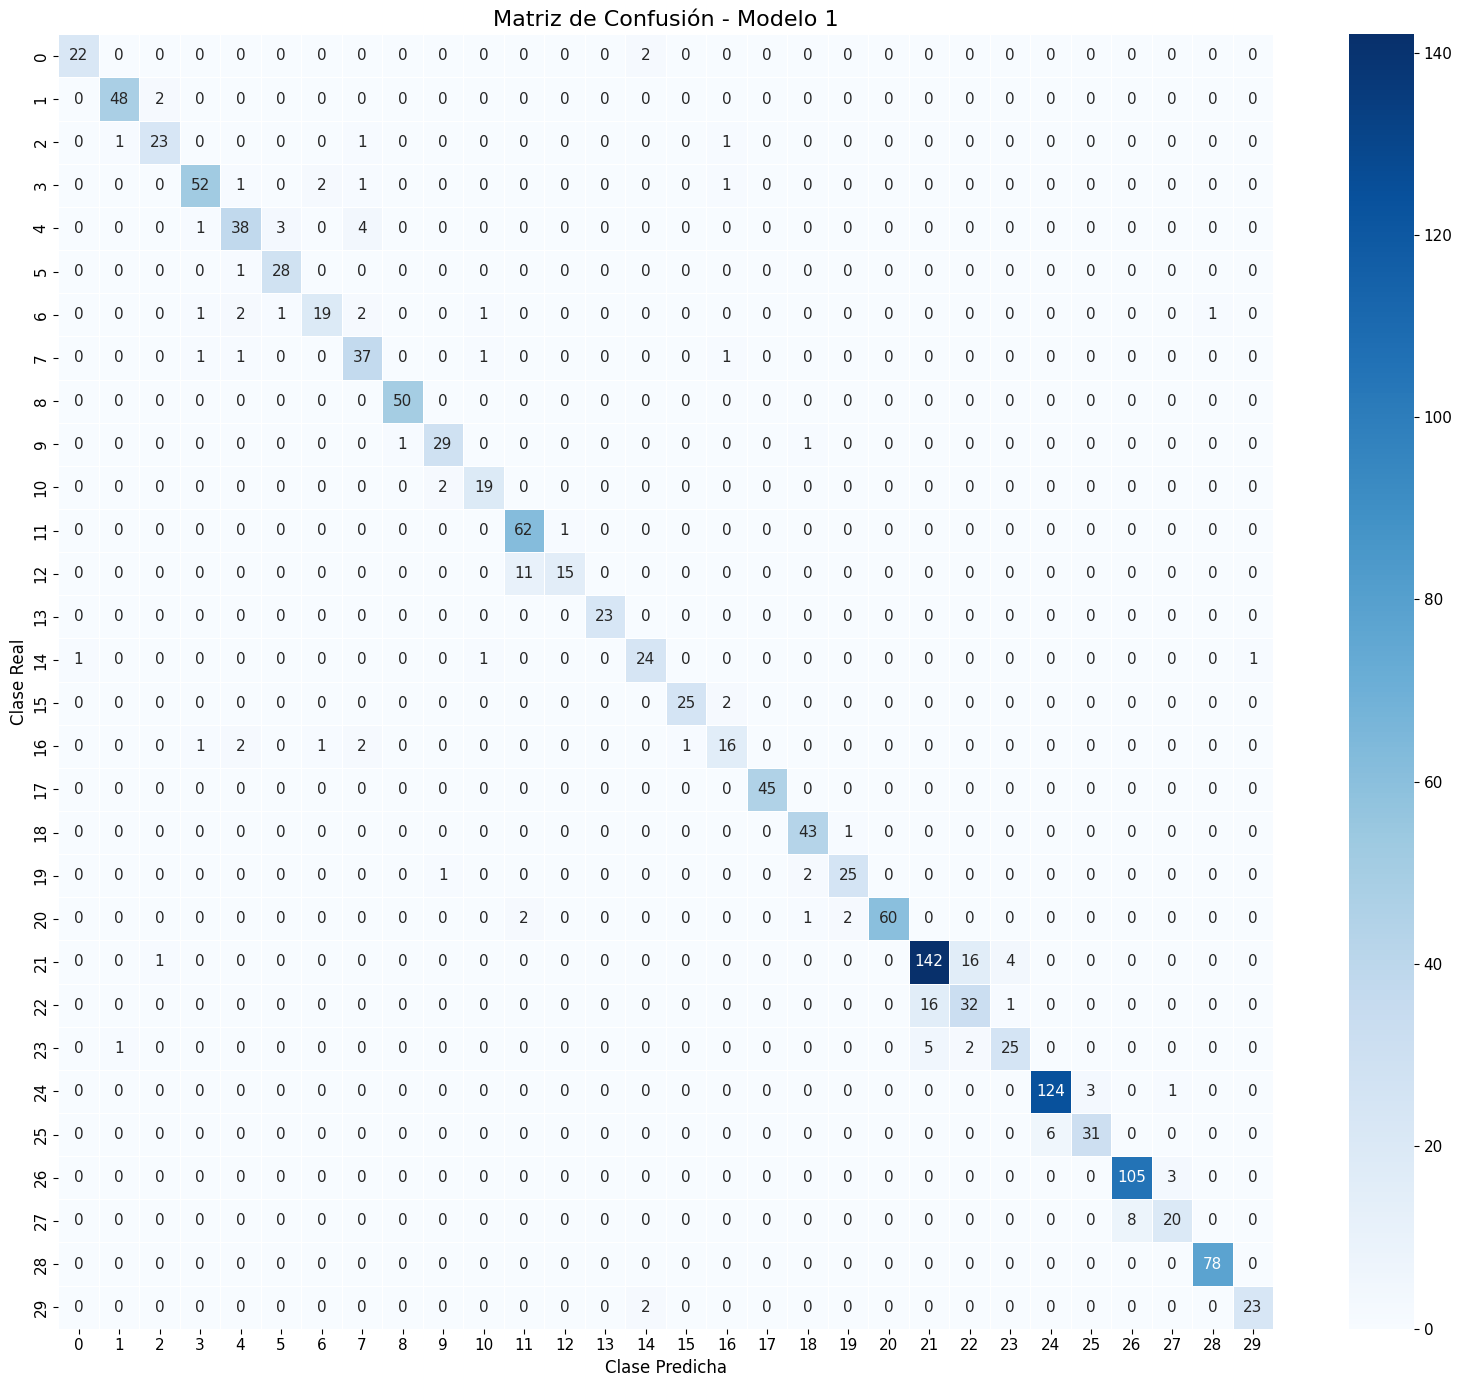

In [84]:
#MATRIZ DE CONFUCION DEL MODELO 1

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_enc, y_pred_1)

plt.figure(figsize=(16, 14))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True,
    linewidths=0.5
)

plt.title(
    'Matriz de Confusión - Modelo 1',
    fontsize=16
)

plt.xlabel(
    'Clase Predicha',
    fontsize=12
)

plt.ylabel(
    'Clase Real',
    fontsize=12
)

plt.tight_layout()

plt.show()